# AuctionUCB-PBM

This notebooks provides all neccessary calculations for the AuctionUCB-PBM experiments.
Logic about evaluating AuctionUCB-PBM is implemeted in the [utils file](./pbm_ucb.py).



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pbm_ucb import main_loop
import pickle
from tqdm import tqdm

from concurrent.futures import ProcessPoolExecutor, as_completed


%load_ext autoreload
%autoreload 2


In [4]:
#UCB
n_iterations = 10_000  #Time horizon
n_repeats = 10_000

"""
Bandit Specification
"""

n_arms = 5 # Number of arms
true_bandit_probs = np.array([0.45, 0.35, 0.25, 0.15, 0.05]) #True reward probability

# Choose one of the next:
prices = 1 / np.array([0.45, 0.35, 0.25, 0.15, 0.05]) ** 1.25 
# prices = np.array([1, 1, 1, 1, 1])
# prices = true_bandit_probs * 10

positions = np.array([0.9, 0.6, 0.3])
delta = 1.5
n_pos = 3

print(prices * true_bandit_probs)

In [6]:
with ProcessPoolExecutor(max_workers=8) as executor:
    exp_futures = {executor.submit(main_loop, n_arms, true_bandit_probs, prices, positions, delta, n_pos, n_iterations, it): it for it in range(n_repeats)}

for future in as_completed(exp_futures):
    internal_config = exp_futures[future]
    exp_result = future.result()


In [7]:
# n_repeats = 10_000
regret_ucb = np.zeros((n_repeats, n_iterations))
regret_base = np.zeros((n_repeats, n_iterations))

for i in tqdm(range(n_repeats)):
    with open(f'datav5/iteration_{i}.pkl', 'rb') as file:
        data = pickle.load(file)
    e_reward_ucb = data['e_reward_ucb']
    e_reward_base = data['e_reward_base']
    e_reward_opt = data['e_reward_opt']
    rew_ucb = data['rew_ucb']
    rew_opt = data['rew_opt']
    rew_base = data['rew_base']

    regret_ucb[i, :] = np.cumsum((e_reward_opt - e_reward_ucb) / e_reward_opt) / np.arange(1, n_iterations + 1)
    regret_base[i, :] = np.cumsum((e_reward_opt - e_reward_base) / e_reward_opt) / np.arange(1, n_iterations + 1)


100%|██████████| 10000/10000 [00:09<00:00, 1065.54it/s]


100%|██████████| 10000/10000 [00:09<00:00, 1109.64it/s]


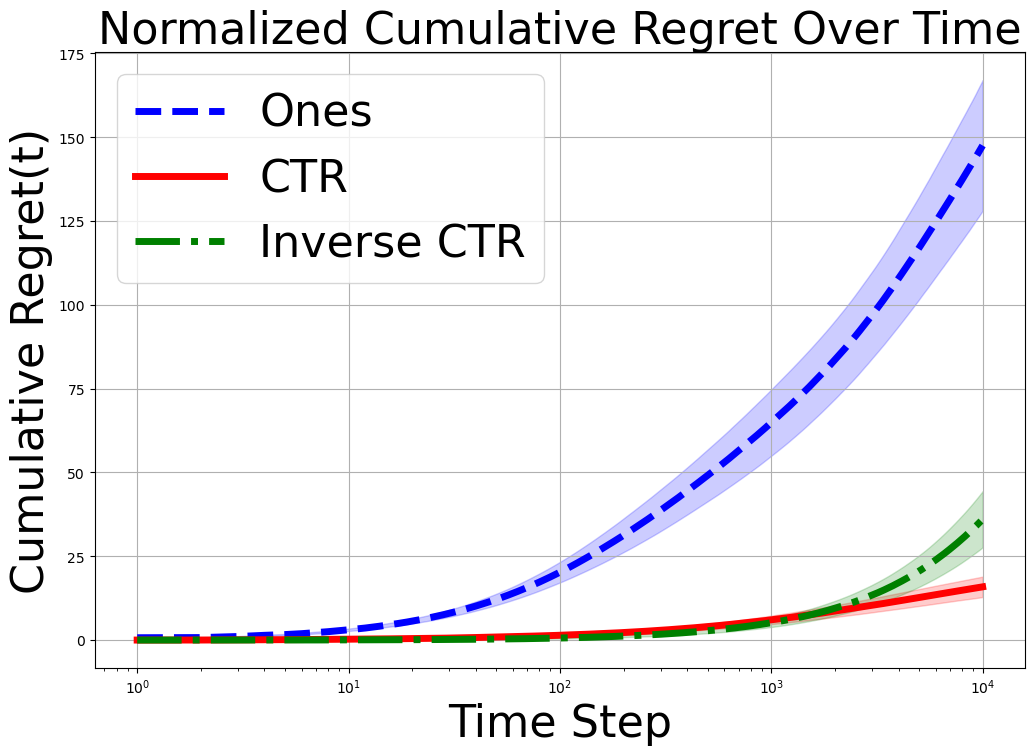

In [15]:
regret_ucb = np.zeros((n_repeats, n_iterations))
regret_base = np.zeros((n_repeats, n_iterations))

plt.figure(figsize=(12, 8))  # Make the picture bigger
FONT_SIZE = 32


for (experiment, path, color, line_style) in zip(
            ["Ones", "CTR", "Inverse CTR"],
            ["datav1", "datav3", "datav4"],
            ["blue", "red", "green"],
            ["--", "-", "-."]):
    for i in tqdm(range(n_repeats)):
        with open(f'{path}/iteration_{i}.pkl', 'rb') as file:
            data = pickle.load(file)
        e_reward_ucb = data['e_reward_ucb']
        e_reward_base = data['e_reward_base']
        e_reward_opt = data['e_reward_opt']
        rew_ucb = data['rew_ucb']
        rew_opt = data['rew_opt']
        rew_base = data['rew_base']

        regret_ucb[i, :] = np.cumsum((e_reward_opt - e_reward_ucb) / e_reward_opt) 
        regret_base[i, :] = np.cumsum((e_reward_opt - e_reward_base) / e_reward_opt)

    regret_ucb = regret_ucb 
    regret_base = regret_base

    mean_ucb = np.mean(regret_ucb, axis=0)
    std_ucb = np.std(regret_ucb, axis=0)
    mean_base = np.mean(regret_base, axis=0)
    std_base = np.std(regret_base, axis=0)

    plt.plot(np.arange(1, n_iterations + 1), mean_ucb, label=experiment, linewidth=5, linestyle=line_style, color=color)  # Increase line width for better visibility
    plt.fill_between(np.arange(1, n_iterations + 1), mean_ucb - std_ucb, mean_ucb + std_ucb, alpha=0.2, color=color)

plt.title('Normalized Cumulative Regret Over Time', fontsize=FONT_SIZE)  # Increase title font size
plt.xlabel('Time Step', fontsize=FONT_SIZE)  # Increase x-axis label font size
plt.ylabel('Cumulative Regret(t)', fontsize=FONT_SIZE)  # Increase y-axis label font size
plt.grid(True)  # Add grid for better readability
plt.xscale('log')
plt.legend(fontsize=FONT_SIZE)  # Increase legend font size
plt.savefig('publish pictures/regret_compare.png')
plt.show()